#### What is a Swarm Plot (swarmplot)?
- A swarm plot is a type of categorical scatter plot that displays the distribution of a numerical variable across different categories. Like a strip plot, it shows every single data point.

- Its key feature is that it uses a deterministic algorithm to position the points along the categorical axis so that they do not overlap. The points are "swarmed" together, creating a visualization that looks like a combination of a strip plot and a histogram or violin plot. The width of the "swarm" at any given point shows the density of the data there.

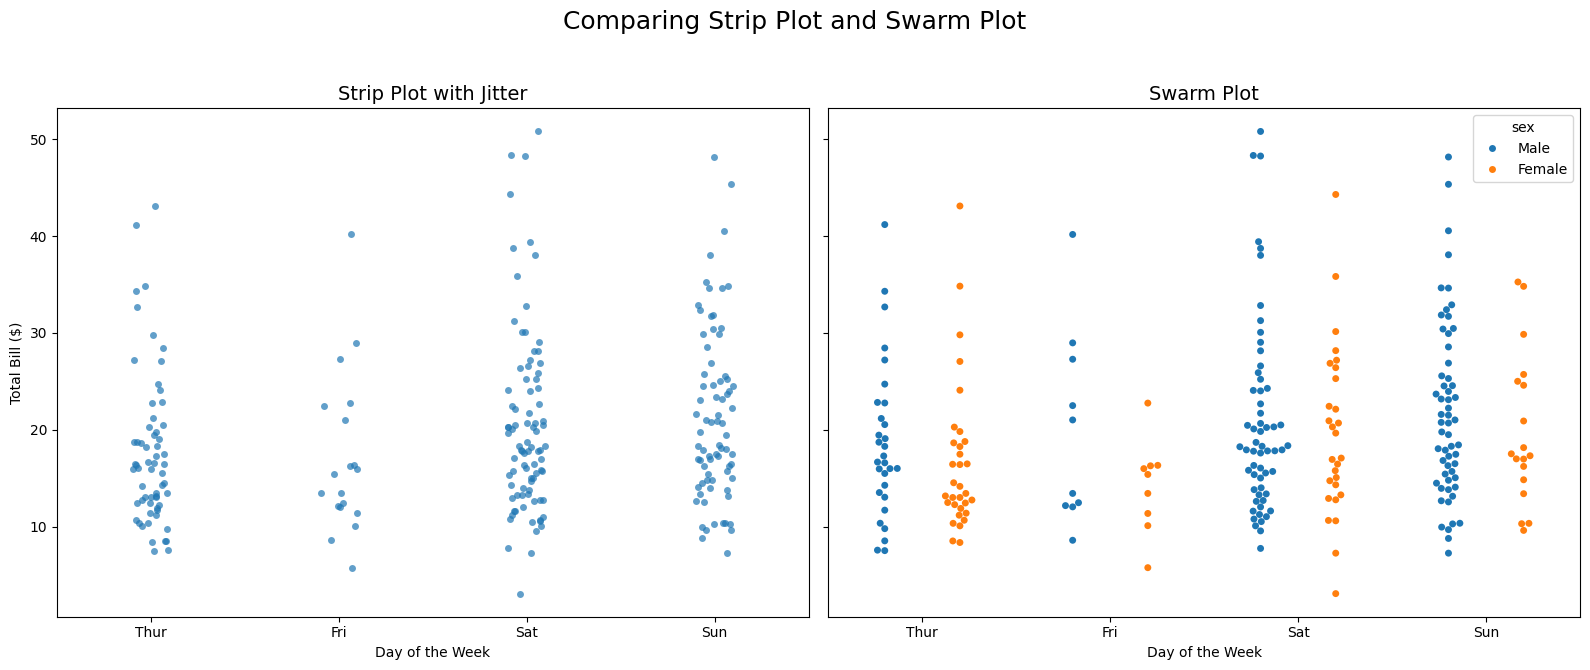

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample Data
# Load the built-in 'tips' dataset from Seaborn
df = sns.load_dataset('tips')

# 2. Sample Code for the Plot

# Create a figure with two subplots to compare
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True) # sharey makes the y-axis consistent


# --- Plot 1: Strip Plot with Jitter (for comparison) ---
sns.stripplot(
    data=df,
    x='day',
    y='total_bill',
    jitter=True,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Strip Plot with Jitter', fontsize=14)
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Total Bill ($)')


# --- Plot 2: The Swarm Plot ---
# Notice how the points are perfectly arranged to avoid overlap.
sns.swarmplot(
    data=df,
    x='day',
    y='total_bill',
    hue='sex', # Color the points by the 'sex' of the tipper
    dodge=True, # Separate the 'hue' categories
    ax=axes[1]
)
axes[1].set_title('Swarm Plot', fontsize=14)
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('') # Remove y-label as it's shared


plt.suptitle('Comparing Strip Plot and Swarm Plot', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### What Type of Information It Provides
A swarm plot provides all the same information as a strip plot but often with much greater clarity.

- Clear Distribution and Density: This is its main advantage. The width of the swarm at any point on the y-axis gives a very accurate representation of the data density. It's like a 1D histogram where you can still see the individual points.

- Precise Data Points: Unlike a strip plot with jitter, the y-position of every point is exact. The x-position is adjusted for visibility, but the y-position is not.

- Outliers and Gaps: It makes outliers and gaps in the data very easy to spot.

- Comparison Across Categories: It's excellent for comparing the distributions between different categories. In our example, you can clearly see the shape of the total_bill distribution for each day.

- Underlying Sample Size: The number of points in each swarm gives a precise count of the observations in each category.



#### Scenarios for Using a Swarm Plot
- During Exploratory Data Analysis (EDA)
- As a Superior Alternative to Strip Plots: For small to medium-sized datasets, a swarm plot is almost always a better choice than a strip plot because it avoids overplotting and provides a clearer view of the distribution.
- Visualizing Numerical vs. Categorical Data: It is one of the best ways to visualize the relationship between a numerical and a categorical variable when you want to see every single data point.
- Identifying Bimodal Distributions: If a category has two distinct clusters of data, a swarm plot will show two "fat" sections, making the bimodal nature obvious.

2. As a Companion to Other Plots
Just like a strip plot, a swarm plot is excellent when overlaid on a box plot or violin plot. This combination provides the statistical summary and the precise location of all the underlying data points.

C:\Users\VimalS\AppData\Local\Temp\ipykernel_16932\309695338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='day', y='total_bill', palette='pastel', inner=None) # inner=None removes the inner boxplot


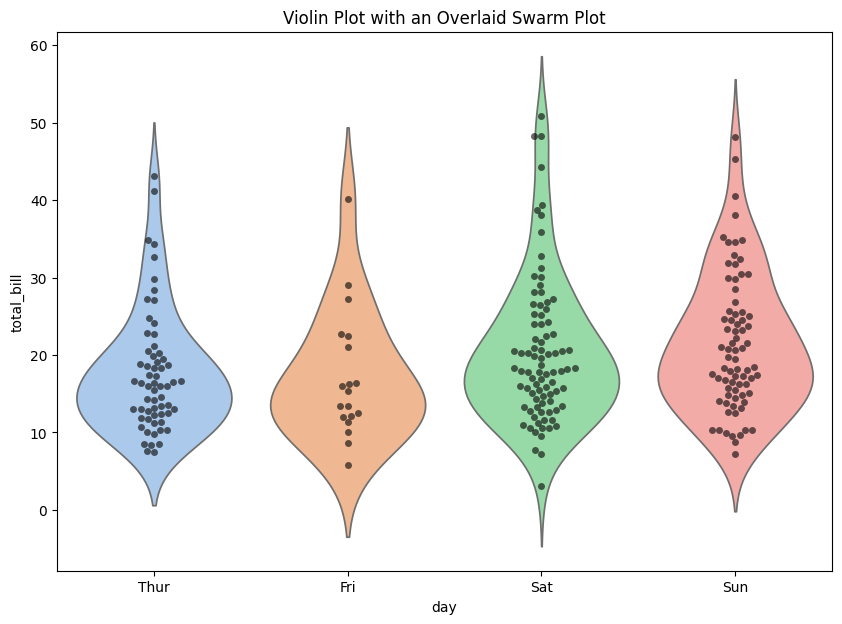

In [2]:
plt.figure(figsize=(10, 7))
sns.violinplot(data=df, x='day', y='total_bill', palette='pastel', inner=None) # inner=None removes the inner boxplot
sns.swarmplot(data=df, x='day', y='total_bill', color='black', alpha=0.6)
plt.title('Violin Plot with an Overlaid Swarm Plot')
plt.show()

#### When Not to Use It
- With Large Datasets: This is the most important limitation. The algorithm to arrange the points without overlap is computationally expensive. If you have too many data points, the algorithm will be very slow, and the plot will become too wide and unreadable. For large datasets, a box plot or violin plot is a much better choice. Seaborn will often raise a warning if you try to use a swarm plot on a large amount of data.
- When a Statistical Summary is Enough: If you only need to compare medians and quartiles, a box plot is simpler and more direct.